In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
import pandas as pd

file_path = '/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv'
df = pd.read_csv(file_path)
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Initial Data Quality Checks

In [ ]:
# 1. Check Number of Rows and Columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# 2. Check Column Names
print("\nColumn Names:")
for col in df.columns:
    print(f"- {col}")

# 3. Check Data Types and Non-Null Counts
print("\nData Types and Missing Values (Info):")
df.info()

# 4. Check Missing Values
print("\nMissing values per column:")
display(df.isnull().sum().to_frame(name='Missing Count'))

# 5. Check Duplicate Records
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

# 6. Basic Statistics for numerical columns
print("\nBasic Statistics:")
display(df.describe())

NameError: name 'df' is not defined

### Data Cleaning

In [ ]:
# 1. Handle Missing Values
print("\nMissing values before cleaning:")
display(df.isnull().sum().to_frame(name='Missing Count'))

initial_rows = df.shape[0]
# Drop rows with any missing values as a default strategy for now.
# In a real scenario, imputation or specific column drops might be considered.
df.dropna(inplace=True)

print(f"\nNumber of rows after dropping missing values: {df.shape[0]} (Dropped {initial_rows - df.shape[0]} rows)")
print("Missing values after cleaning:")
display(df.isnull().sum().to_frame(name='Missing Count'))


Missing values before cleaning:


,Missing Count
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0



Number of rows after dropping missing values: 301 (Dropped 0 rows)
Missing values after cleaning:


,Missing Count
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
# 2. Handle Duplicate Rows
print("\nNumber of duplicate rows before cleaning:", df.duplicated().sum())

initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)

print(f"Number of rows after dropping duplicates: {df.shape[0]} (Dropped {initial_rows - df.shape[0]} rows)")
print("Number of duplicate rows after cleaning:", df.duplicated().sum())


Number of duplicate rows before cleaning: 2
Number of rows after dropping duplicates: 299 (Dropped 2 rows)
Number of duplicate rows after cleaning: 0


In [ ]:
# 3. Review Data Types
print("\nData Types after cleaning:")
df.info()

# The data types generally appear appropriate based on initial inspection.
# 'Year' could be datetime if further time-series analysis is needed,
# but for general trends, integer is fine. 'Owner' is likely categorical.


Data Types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Seller_Type    299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [ ]:
# 4. Review Unnecessary Columns
# Based on the current problem statement (Car Market Trends Analysis),
# all current columns seem potentially relevant. If specific columns were consistently
# empty, had too many unique values for a categorical feature, or were redundant,
# we would drop them here.

print("\nFinal DataFrame head after cleaning:")
display(df.head())
print("Final DataFrame shape after cleaning:", df.shape)


Final DataFrame head after cleaning:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Final DataFrame shape after cleaning: (299, 9)


### Cars by Fuel Type - Pie Chart

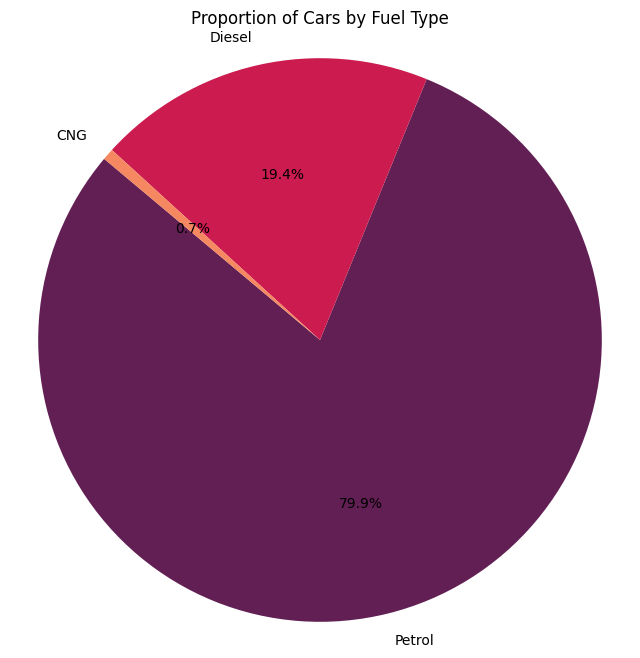

In [ ]:
# Calculate the proportion of cars by Fuel_Type
fuel_type_counts = df['Fuel_Type'].value_counts()

# Create the pie chart with 'rocket' inspired colors
fig = plt.figure(figsize=(8, 8))
plt.pie(fuel_type_counts, labels=fuel_type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('rocket', n_colors=len(fuel_type_counts)))
plt.title('Proportion of Cars by Fuel Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Average Selling Price by Fuel Type - Bar Chart

/tmp/ipykernel_945/2736340258.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel_Type', y='Selling_Price', data=average_selling_price_by_fuel, palette='rocket')


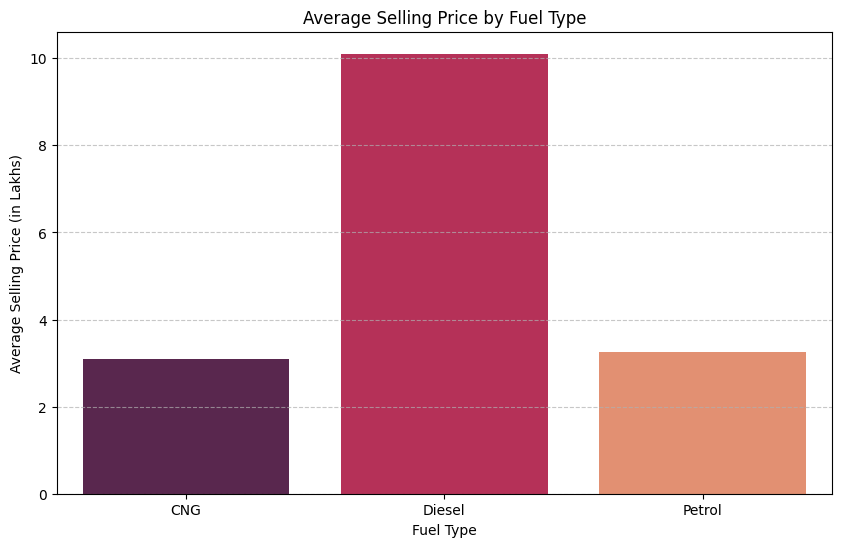

In [ ]:
# Calculate the average selling price for each fuel type
average_selling_price_by_fuel = df.groupby('Fuel_Type')['Selling_Price'].mean().reset_index()

# Create the bar chart
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Fuel_Type', y='Selling_Price', data=average_selling_price_by_fuel, palette='rocket')
plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (in Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Present Price vs Selling Price - line chart


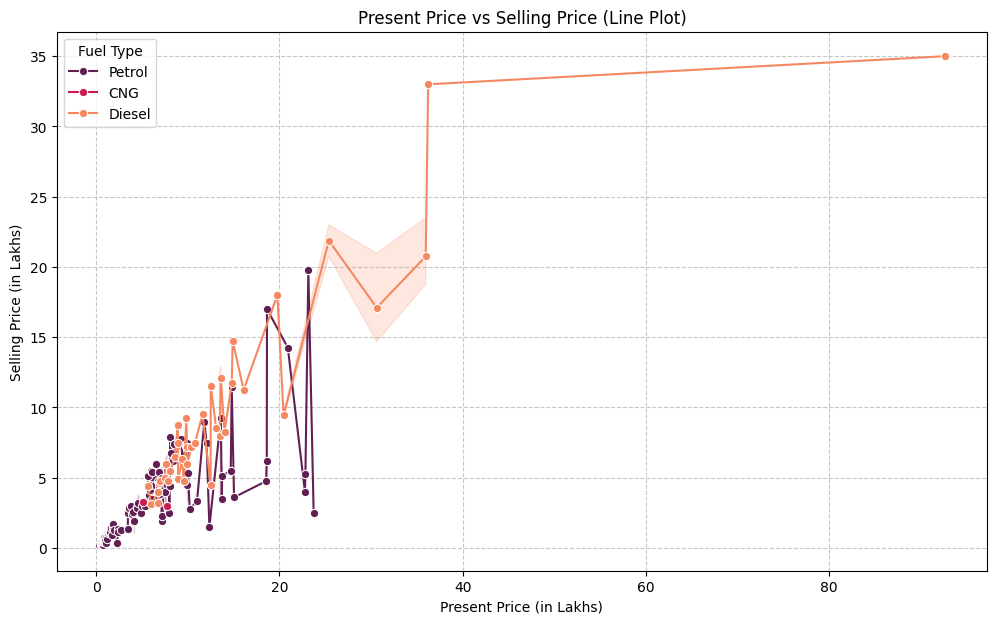

In [ ]:
# Create bins for 'Present_Price' to group data
max_present_price = df['Present_Price'].max()
bins = [i for i in range(0, int(max_present_price) + 6, 5)] # Bins of 5 lakhs
labels = [f'{i}-{i+5}L' for i in range(0, int(max_present_price) + 1, 5) if i < max_present_price]
# Handle the last label if max_present_price falls exactly on a bin boundary or between the last full bin and max
if max_present_price > bins[-2]:
    labels[-1] = f'{bins[-2]}-{int(max_present_price)+1}L' # Adjust last label if needed

df['Present_Price_Bins'] = pd.cut(df['Present_Price'], bins=bins, labels=labels, right=False, include_lowest=True)

# Calculate the average selling price for each Present_Price bin, grouped by Fuel_Type
average_selling_price_by_present_price_bin = df.groupby(['Present_Price_Bins', 'Fuel_Type'])['Selling_Price'].mean().reset_index()

# Create the grouped bar chart
fig = plt.figure(figsize=(14, 8))
sns.barplot(x='Present_Price_Bins', y='Selling_Price', hue='Fuel_Type', data=average_selling_price_by_present_price_bin, palette='rocket')
plt.title('Average Selling Price by Present Price Range and Fuel Type')
plt.xlabel('Present Price Range (in Lakhs)')
plt.ylabel('Average Selling Price (in Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

### Kilometers Driven vs Selling Price - Scatter Plot

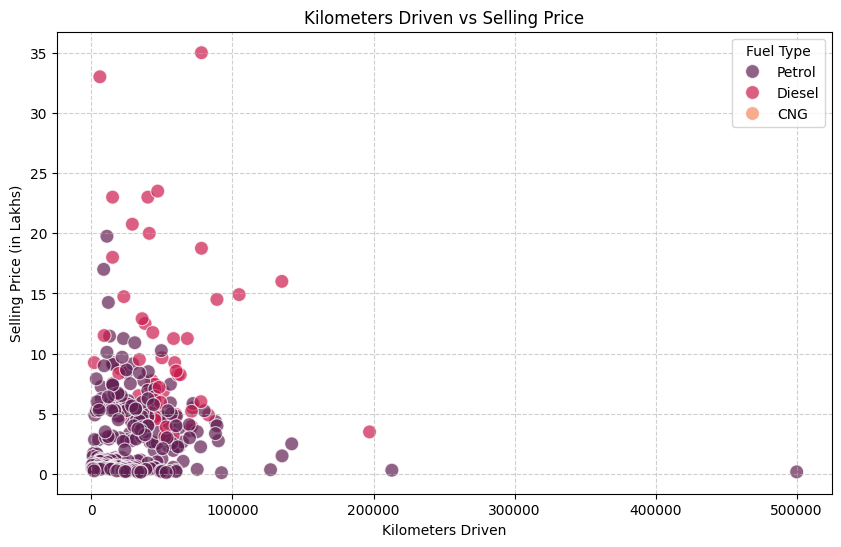

In [ ]:
# Create the scatter plot for Kilometers Driven vs Selling Price
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, hue='Fuel_Type', palette='rocket', s=100, alpha=0.7)
plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (in Lakhs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Fuel Type')
plt.show()

### Average Selling Price by Kilometers Driven Ranges - Column Chart

/tmp/ipykernel_945/107277064.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_selling_price_by_kms_bin = df.groupby(['Kms_Driven_Bins', 'Fuel_Type'])['Selling_Price'].mean().reset_index()


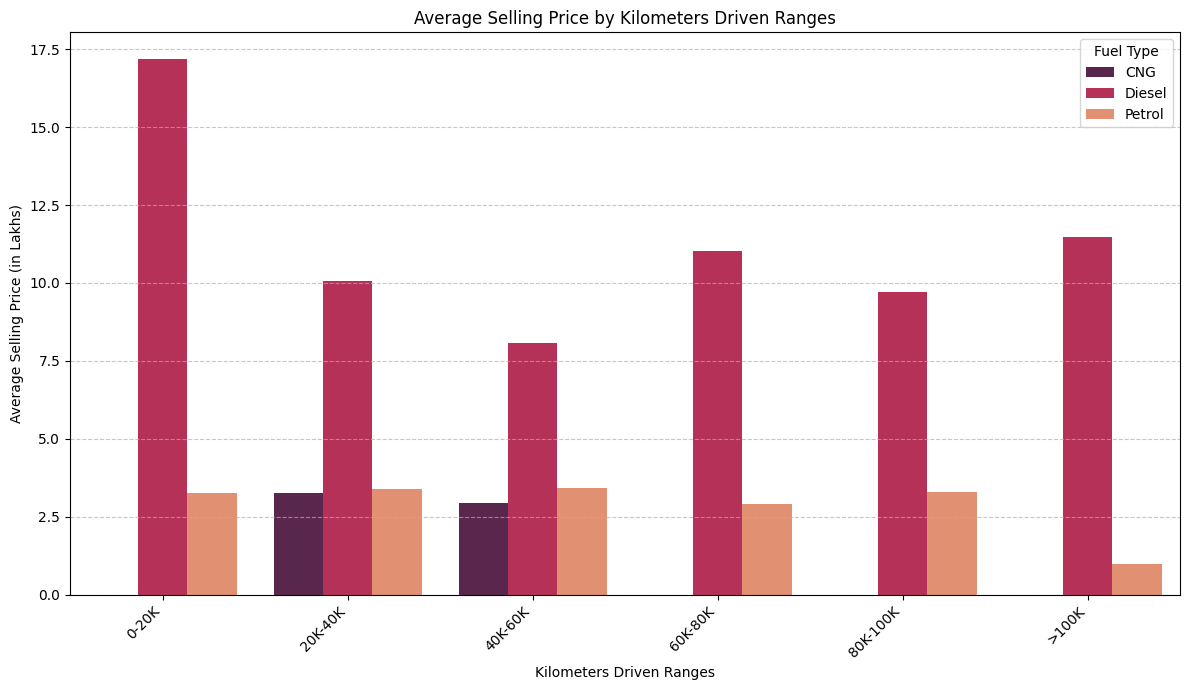

In [ ]:
# Create bins for 'Kms_Driven'
bins = [0, 20000, 40000, 60000, 80000, 100000, df['Kms_Driven'].max() + 1]
labels = ['0-20K', '20K-40K', '40K-60K', '60K-80K', '80K-100K', '>100K']
df['Kms_Driven_Bins'] = pd.cut(df['Kms_Driven'], bins=bins, labels=labels, right=False)

# Calculate the average selling price for each Kms_Driven bin, optionally by Fuel_Type
average_selling_price_by_kms_bin = df.groupby(['Kms_Driven_Bins', 'Fuel_Type'])['Selling_Price'].mean().reset_index()

# Create the bar chart
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Kms_Driven_Bins', y='Selling_Price', hue='Fuel_Type', data=average_selling_price_by_kms_bin, palette='rocket')
plt.title('Average Selling Price by Kilometers Driven Ranges')
plt.xlabel('Kilometers Driven Ranges')
plt.ylabel('Average Selling Price (in Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

### Selling Price Trend by Manufacturing Year - Line Chart

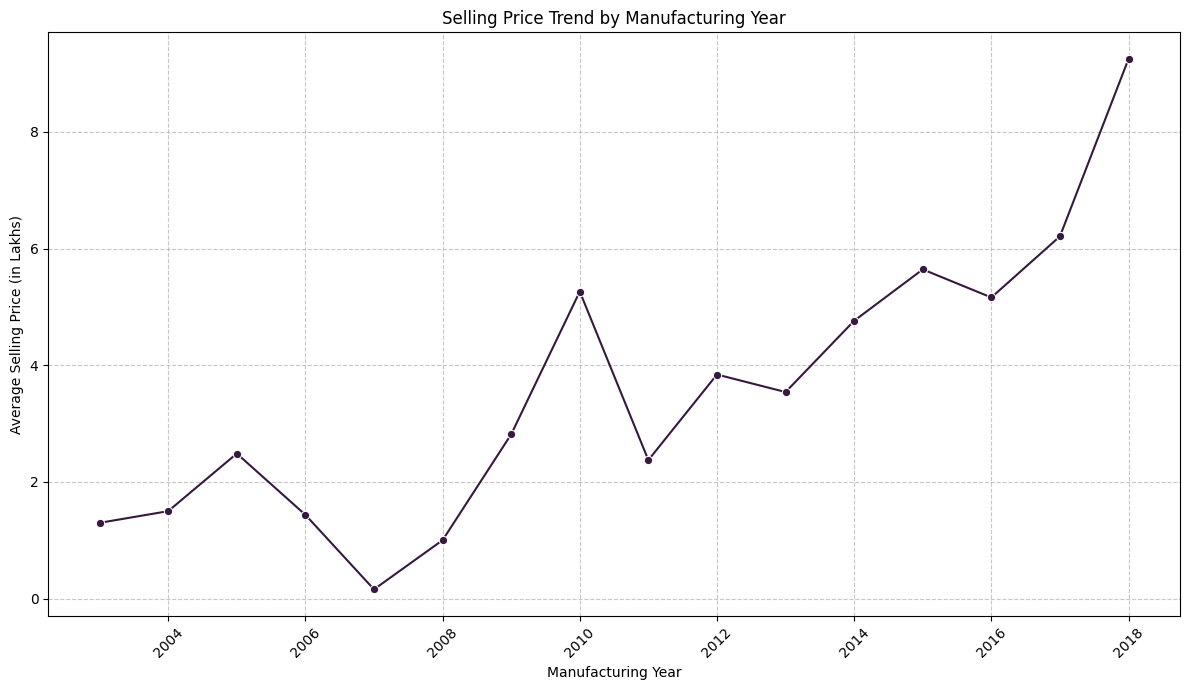

In [ ]:
# Calculate the average selling price for each manufacturing year
average_selling_price_by_year = df.groupby('Year')['Selling_Price'].mean().reset_index()

# Create the line chart
fig = plt.figure(figsize=(12, 7))
sns.lineplot(x='Year', y='Selling_Price', data=average_selling_price_by_year, marker='o', color=sns.color_palette('rocket')[0]) # Use a single color from rocket for lineplot without hue
plt.title('Selling Price Trend by Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Average Selling Price (in Lakhs)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Selling Price Distribution - Box Plot

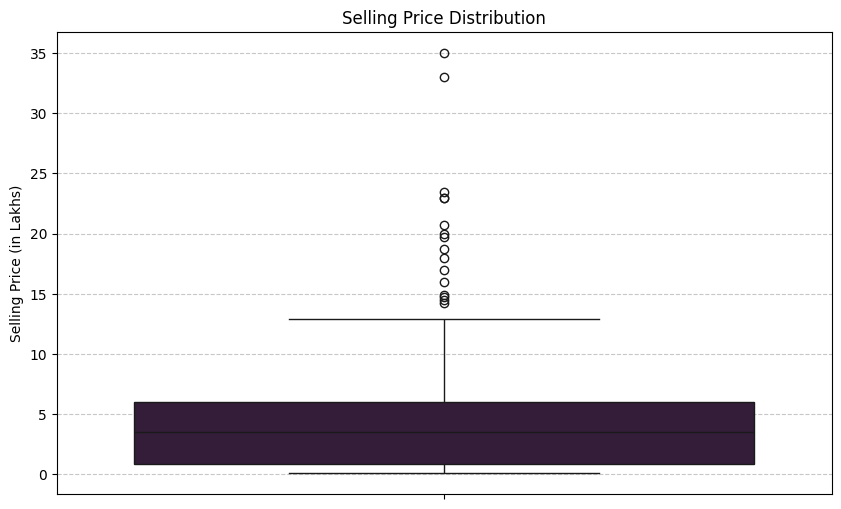

In [ ]:
# Create a box plot for Selling Price Distribution
fig = plt.figure(figsize=(10, 6))
sns.boxplot(y='Selling_Price', data=df, color=sns.color_palette('rocket')[0]) # Use a single color from rocket
plt.title('Selling Price Distribution')
plt.ylabel('Selling Price (in Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Selling Price by Transmission - Bar Chart

/tmp/ipykernel_945/1810970231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transmission', y='Selling_Price', data=average_selling_price_by_transmission, palette='rocket')


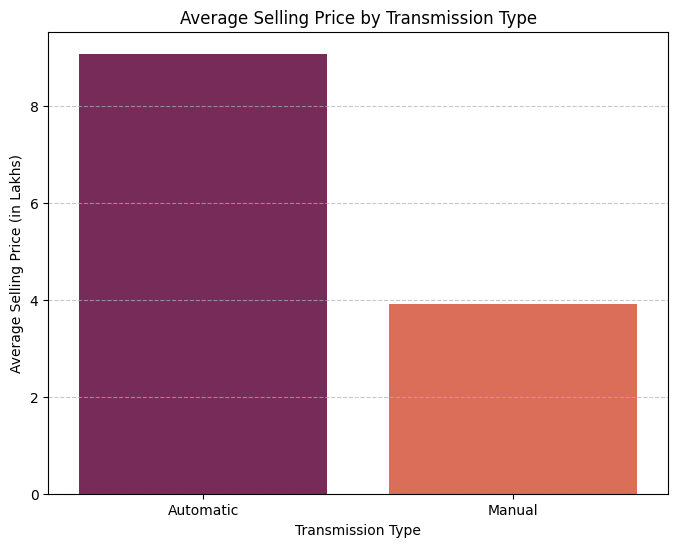

In [ ]:
# Calculate the average selling price for each transmission type
average_selling_price_by_transmission = df.groupby('Transmission')['Selling_Price'].mean().reset_index()

# Create the bar chart
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Transmission', y='Selling_Price', data=average_selling_price_by_transmission, palette='rocket')
plt.title('Average Selling Price by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Average Selling Price (in Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Selling Price by Seller Type - Donut Chart

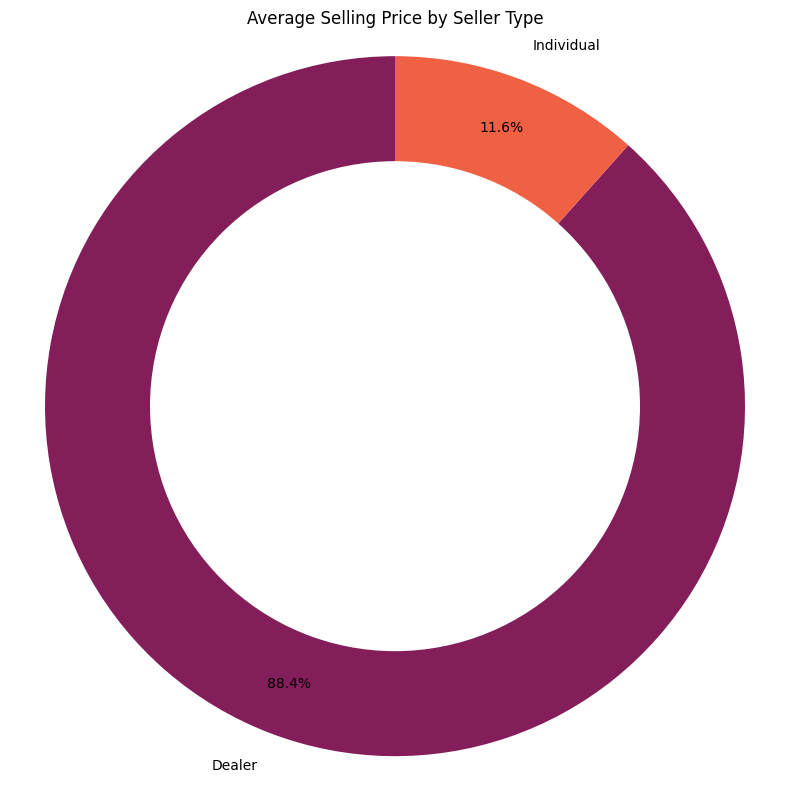

In [ ]:
# Calculate the distribution of cars by Seller_Type
seller_type_counts = df['Seller_Type'].value_counts()

# Create the donut chart with 'rocket' inspired colors
fig = plt.figure(figsize=(8, 8))
plt.pie(seller_type_counts, labels=seller_type_counts.index,
        autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=sns.color_palette('rocket', n_colors=len(seller_type_counts)))

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Cars by Seller Type') # Renamed title
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Car Age Distribution - Histogram

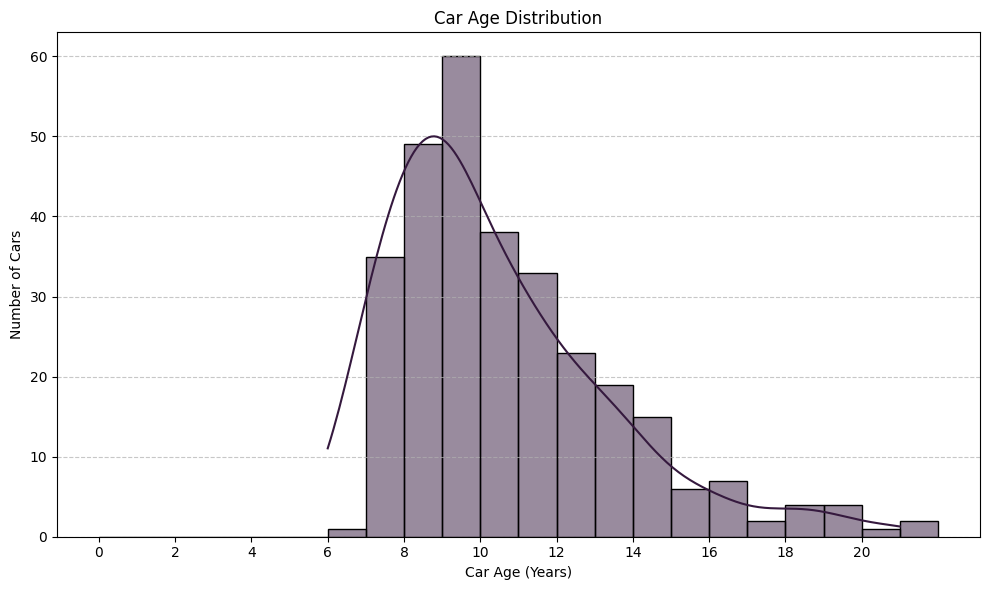

In [ ]:
# Calculate car age
current_year = 2024 # Assuming current year for age calculation
df['Car_Age'] = current_year - df['Year']

# Create the histogram for Car Age Distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(df['Car_Age'], bins=range(0, df['Car_Age'].max() + 2), kde=True, color=sns.color_palette('rocket')[0]) # Use a single color from rocket for histogram without hue
plt.title('Car Age Distribution')
plt.xlabel('Car Age (Years)')
plt.ylabel('Number of Cars')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, df['Car_Age'].max() + 1, 2))
plt.tight_layout()
plt.show()

### Correlation Between Numerical Features - Heatmap

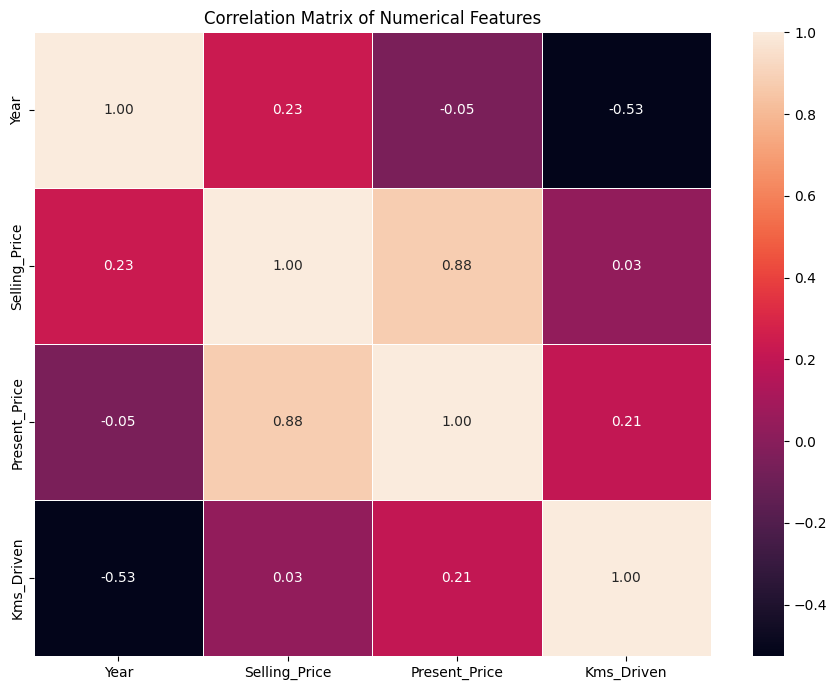

In [ ]:
# Select the numerical features for correlation analysis
numerical_features = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven']
correlation_matrix = df[numerical_features].corr()

# Create the heatmap with 'rocket' colormap
fig = plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### Top 10 Most Expensive Car Models - Horizontal Bar Chart

In [ ]:
# Calculate the average selling price for each car model
average_selling_price_by_model = df.groupby('Car_Name')['Selling_Price'].mean().reset_index()

# Sort by selling price in descending order and get the top 10
top_10_expensive_cars = average_selling_price_by_model.sort_values(by='Selling_Price', ascending=False).head(10)

display(top_10_expensive_cars)

,Car_Name,Selling_Price
88,land cruiser,35.000000
81,fortuner,18.254000
86,innova,12.777778
72,creta,11.800000
74,elantra,11.600000
95,vitara brezza,9.250000
68,ciaz,7.472222
69,city,7.419231
71,corolla altis,7.183125
76,ertiga,6.580000


/tmp/ipykernel_945/2969720993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Selling_Price', y='Car_Name', data=top_10_expensive_cars, palette='rocket')


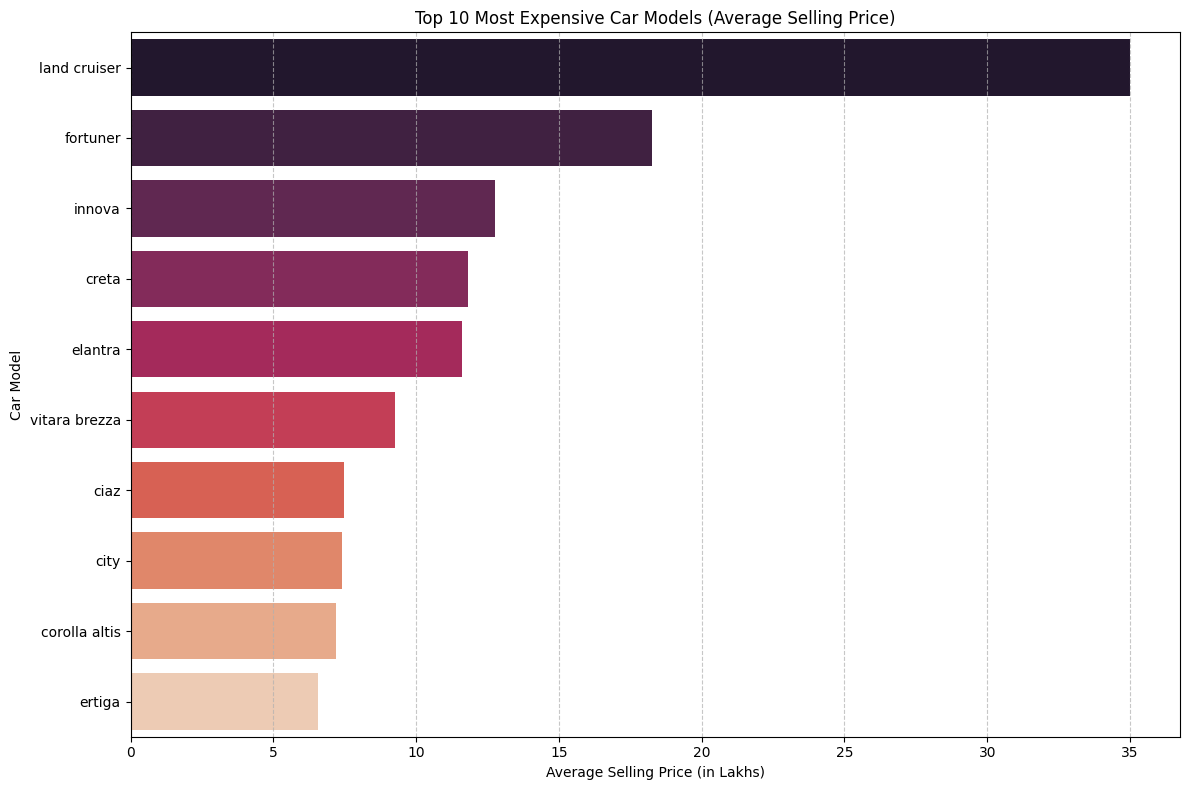

In [ ]:
# Create the horizontal bar chart
fig = plt.figure(figsize=(12, 8))
sns.barplot(x='Selling_Price', y='Car_Name', data=top_10_expensive_cars, palette='rocket')
plt.title('Top 10 Most Expensive Car Models (Average Selling Price)')
plt.xlabel('Average Selling Price (in Lakhs)')
plt.ylabel('Car Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()